In [22]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import seaborn as sns

import matplotlib.pyplot as plt

# Intro

The objective here is to investigate possible user-clustering. In particular, from the results (all tasks) we see that there is large user variability and, for some users, the performance is really bad. I want to understand here if there is some correlation with the data, or not.

### USILaughs - congitive load

In [3]:
data = np.load("../data.nosync/usilaughs/data_right_cognitiveload_60s.npz")

In [67]:
X = data["values"]          # shape: (90, 240, 3)

# Flatten each sample from (240, 3) -> (720,)
X_flat = X.reshape(X.shape[0], -1)

# t-SNE to 2D
X_2d = TSNE(
    n_components=2,
    perplexity=10,
    init="pca",
    learning_rate="auto",
    random_state=42,
).fit_transform(X_flat)

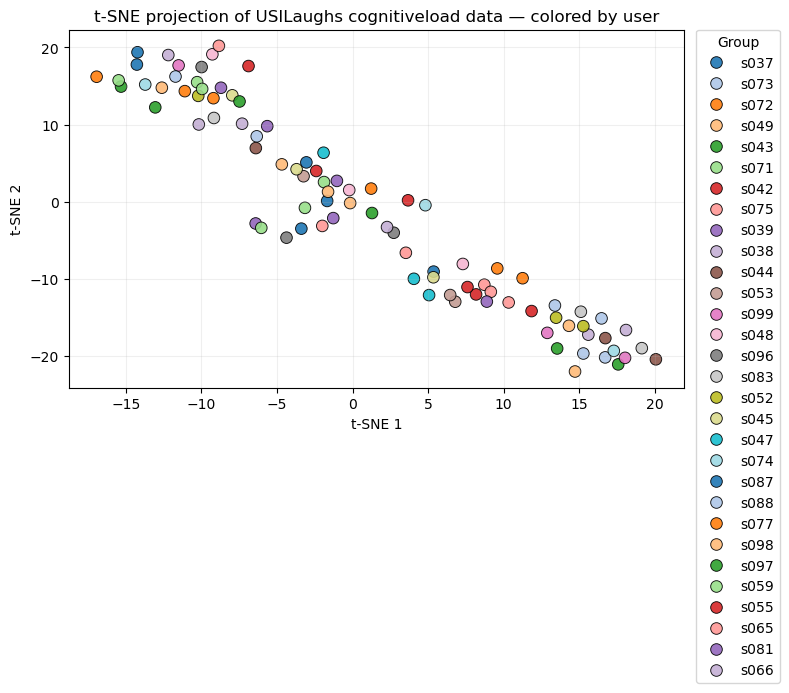

Original shape: (90, 240, 3)
Reduced shape: (90, 2)


In [68]:

# Plot with seaborn (categorical hue for subject/group IDs)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=data['groups'],
    palette="tab20",
    s=70,
    alpha=0.9,
    edgecolor="k",
)

plt.title("t-SNE projection of USILaughs cognitiveload data — colored by user")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.2)

# Move legend outside to keep plot readable
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("Original shape:", X.shape)
print("Reduced shape:", X_2d.shape)


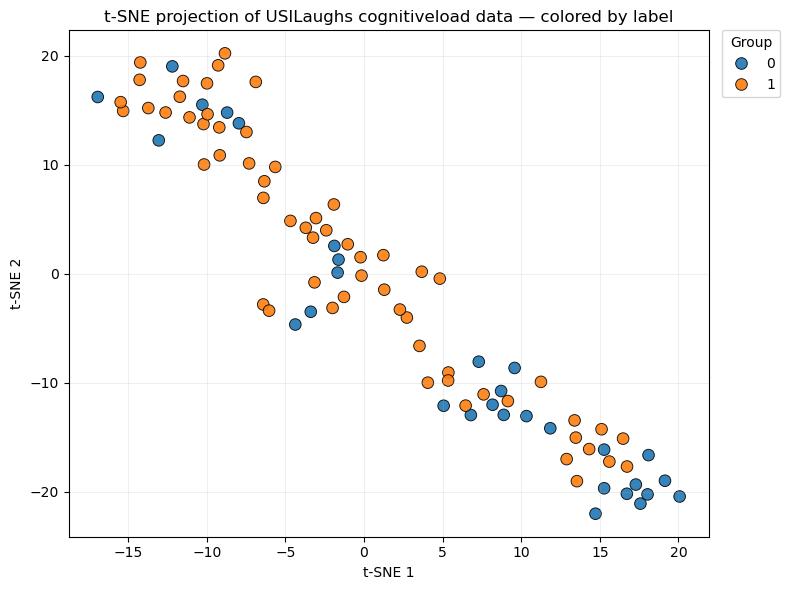

Original shape: (90, 240, 3)
Reduced shape: (90, 2)


In [69]:

# Plot with seaborn (categorical hue for subject/group IDs)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=data['labels'],
    s=70,
    alpha=0.9,
    edgecolor="k",
)

plt.title("t-SNE projection of USILaughs cognitiveload data — colored by label")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.2)

# Move legend outside to keep plot readable
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("Original shape:", X.shape)
print("Reduced shape:", X_2d.shape)


In [70]:
results = pd.read_csv(
    "../outputs/usilaughs-right/multirun_2026-01-12-16-28-21/0/reports.csv", index_col=0
)
print(
    "Balanced accuracy for UME + logistic regression: %i ± %i %%"
    % (
        results["balanced_accuracy_score"].mean() * 100,
        results["balanced_accuracy_score"].sem() * 1.98 * 100,
    )
)

results['user'] = np.unique(data['groups'])

Balanced accuracy for UME + logistic regression: 70 ± 10 %


In [71]:
acc_user = np.array([results[results['user'] == val]['balanced_accuracy_score'].iloc[0] for val in data['groups']])

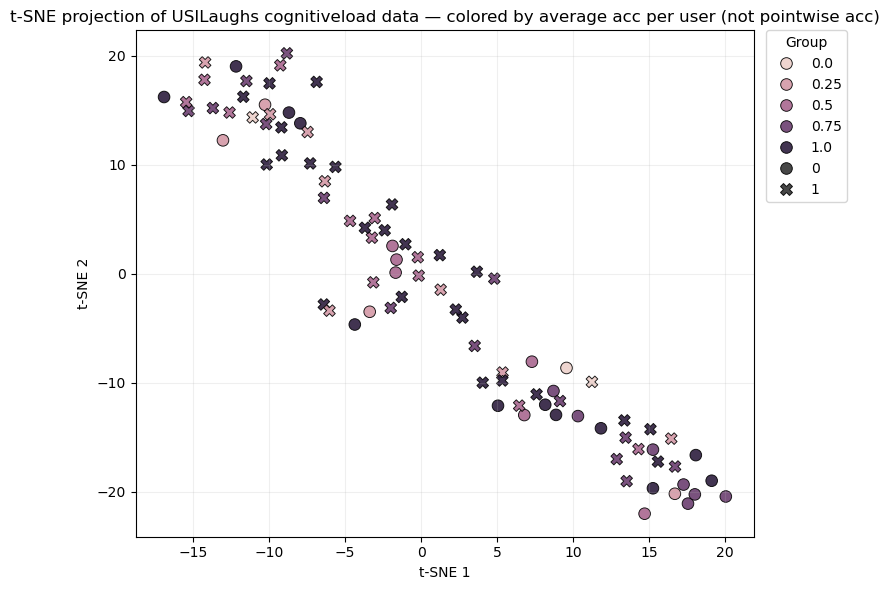

Original shape: (90, 240, 3)
Reduced shape: (90, 2)


In [72]:

# Plot with seaborn (categorical hue for subject/group IDs)
plt.figure(figsize=(8, 6))
ax = sns.scatterplot(
    x=X_2d[:, 0],
    y=X_2d[:, 1],
    hue=acc_user,
    style=data['labels'].astype(str),  # Different marker for each label
    # palette="tab10",
    s=70,
    alpha=0.9,
    edgecolor="k",
)

plt.title("t-SNE projection of USILaughs cognitiveload data — colored by average acc per user (not pointwise acc)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.grid(alpha=0.2)

# Move legend outside to keep plot readable
plt.legend(title="Group", bbox_to_anchor=(1.02, 1), loc="upper left", borderaxespad=0)
plt.tight_layout()
plt.show()

print("Original shape:", X.shape)
print("Reduced shape:", X_2d.shape)
